# Praktische Übung 1: Pandas

Lösen Sie die nachfolgenden Aufgaben und nutzen Sie das in der Vorlesung gezeigte Notebook `0_Pandas_Intro.ipynb` als Lösungshilfe.

In [2]:
import pandas as pd

df = pd.read_csv("data/automobile.csv")

df

,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
0,0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0
1,1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0
2,2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0
3,3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0
4,4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0
...,...,...,...,...,...,...,...,...,...,...
56,81,volkswagen,sedan,97.3,171.7,ohc,four,85,27,7975.0
57,82,volkswagen,sedan,97.3,171.7,ohc,four,52,37,7995.0
58,86,volkswagen,sedan,97.3,171.7,ohc,four,100,26,9995.0
59,87,volvo,sedan,104.3,188.8,ohc,four,114,23,12940.0


## Aufgabe 1

1. Laden Sie den Datensatz `automobile.csv` von GitHub aus dem Folder `data` runter.
2. Laden Sie die Daten in diesem Notebook in einen Pandas DataFrame.
3. Schauen Sie sich die Daten an und versuchen Sie zu verstehen was die Daten abbilden.
4. Geben Sie folgende Daten aus:
    1. Eine Liste aller Hersteller.
    2. Wie oft welcher „body-style“ im Datensatz vorhanden ist.
    3. Die fünf Autos mit dem niedrigsten Preis.
    4. Die fünf Autos mit dem höchsten Preis

In [3]:
# 1
#df["company"]

# 2
#df["body-style"].value_counts()

# 3
#df.sort_values("price", ascending=True).head(5)

# 4
df.sort_values("price", ascending=False).head(5)

,index,company,body-style,wheel-base,length,engine-type,num-of-cylinders,horsepower,average-mileage,price
35,47,mercedes-benz,hardtop,112.0,199.2,ohcv,eight,184,14,45400.0
11,14,bmw,sedan,103.5,193.8,ohc,six,182,16,41315.0
34,46,mercedes-benz,sedan,120.9,208.1,ohcv,eight,184,14,40960.0
46,62,porsche,convertible,89.5,168.9,ohcf,six,207,17,37028.0
12,15,bmw,sedan,110.0,197.0,ohc,six,182,15,36880.0


## Aufgabe 2

1. Was ist der durchschnittliche Preis mit Bezug auf den „body-style“ eines Autos?
2. Welches sind die drei „body-style“s mit den durchschnittlich höchsten Preisen?
3. Welche Companies stellen „hardtop“ als „body-style“ her?
4. Geben Sie alle Autos aus deren Herstellernamen mit "a" oder "b" beginnt ([Hint](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.startswith.html)).
5. Erstellen Sie je einen Scatterplot mit:
    1. Scatterplot mit `x="horsepower"` und `y="average-mileage"`
    2. Scatterplot mit `x="horsepower"` und `y="price"`

<Axes: xlabel='horsepower', ylabel='price'>

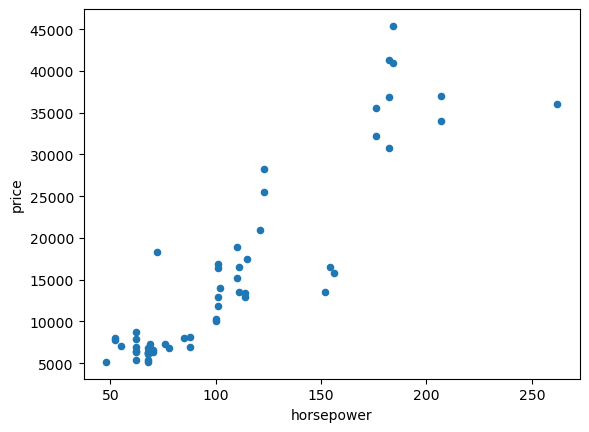

In [4]:
# 1
#df[["body-style", "price"]].groupby("body-style").mean()

# 2
#df[["body-style", "price"]].groupby("body-style").mean().sort_values("price", ascending=False).head(3)

# 3
#df[df["body-style"] == "hardtop"]["company"]

# 4
df[df["company"].str.startswith("a")]

# 5.1
#df.plot.scatter(x="horsepower", y="average-mileage")
# 5.2
df.plot.scatter(x="horsepower", y="price")
   


## Aufgabe 3

1. Zusätzlich stehen ihnen nachfolgende Informationen zur Verfügung. Erstellen Sie einen zweiten DataFrame, der diese Informationen enthält.

|company|country|
|--- |--- |
|alfa-romero|ITA|
|audi|GER|
|bmw|GER|
|volvo|SWE|
|nissan|JAP|
|mazda|JAP|

2. Verbinden Sie die zwei DataFrames über einen `merge` ([Hint](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)). Stellen Sie sicher, dass die Datenpunkte welche keine Länderangabe haben nicht verloren gehen.
3. Geben Sie in einem DataFrame aus, wieviel Fahrzeuge pro Land vorhanden sind und wie hoch der Durchschnittspreis pro Land liegt.

In [20]:
data = {
    "company": ["alfa-romero", "audi", "bmw", "volvo", "nissan", "mazda"],
    "country": ["ITA", "GER", "GER", "SWE", "JAP", "JAP"]
}
ndf = pd.DataFrame(data)

mdf = df.merge(ndf, "outer")

mdf[["price", "country"]].groupby("country").agg(["count", "mean"])

price              
        count          mean
country                    
GER        10  22885.000000
ITA         3  15498.333333
JAP        10   8971.900000
SWE         2  13177.500000

## Bonus

Folgende Aufgaben sind als Bonus gedacht (für diejenigen die mit den vorherigen Aufgaben schon durch sind). Um sie zu lösen muss selbstständig nach den benötigten Methoden im Internet gesucht werden. 
1. Entfernen Sie die Spalte „body-styles“ vom DataFrame.
2. Erstellen Sie einen neuen DataFrame der 10% zufällig ausgewählte Zeilen aus dem ursprünglichen DataFrame enthält.
3. Fügen Sie die Zeilen des neuen DataFrames an den ursprünglichen DataFrame unten ran.
4. Zählen Sie die Anzahl doppelter Einträge in diesem DataFrame.

In [ ]:
# 1
#df.drop("body-style", axis=1)

# 2
sdf = df.sample(frac=0.1)

# 3
edf = pd.concat([df, sdf], ignore_index=True)
edf.duplicated().sum()

np.int64(6)